In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
from datetime import date
from dotenv import load_dotenv
import os
import sys
from tqdm import tqdm
import datetime as dt

load_dotenv()

True

In [2]:
to_date = lambda t: dt.datetime.strptime(t,'%m/%d/%Y %H')

In [25]:
man_df = pd.read_csv('data/rt_hourlysysload_20260123_20260206.csv', skiprows=4)[1:361]

In [28]:
to_date = lambda t: dt.datetime.strptime(t,'%m/%d/%Y %H')
man_df['datetime'] = pd.to_datetime((man_df['Date']+ ' ' + (man_df['Hour Ending'].astype(int) - 1).astype('str')).apply(to_date))
man_df = man_df.set_index('datetime').tz_localize("US/Eastern")
man_df['Total Load'] = man_df['Total Load'].astype('float')
man_df[['Total Load']].resample('D').sum()

,Total Load
datetime,
2026-01-23 00:00:00-05:00,371578.18
2026-01-24 00:00:00-05:00,407080.58
2026-01-25 00:00:00-05:00,437092.64
2026-01-26 00:00:00-05:00,416560.40
2026-01-27 00:00:00-05:00,425550.34
2026-01-28 00:00:00-05:00,423767.79
2026-01-29 00:00:00-05:00,423754.76
2026-01-30 00:00:00-05:00,434919.40
2026-01-31 00:00:00-05:00,415984.23


In [6]:
rt_df = pd.read_csv("data/isone_load_2026-01-23_2026-02-11.csv", parse_dates=True, index_col='datetime')
rt_df

,4001,4002,4003,4004,4005,4006,4007,4008
datetime,,,,,,,,
2026-01-23 00:00:00-05:00,1265.895,1267.846,648.409,2971.238,799.596,1523.100,1856.100,2613.693
2026-01-23 01:00:00-05:00,1231.230,1238.156,633.219,2897.949,778.257,1484.489,1814.346,2539.647
2026-01-23 02:00:00-05:00,1228.882,1230.790,626.191,2872.793,770.683,1471.913,1792.794,2515.273
2026-01-23 03:00:00-05:00,1244.951,1239.356,628.621,2884.591,773.145,1479.510,1796.869,2524.869
2026-01-23 04:00:00-05:00,1295.125,1282.323,643.655,2980.483,794.124,1512.859,1843.787,2599.861
...,...,...,...,...,...,...,...,...
2026-02-11 19:00:00-05:00,1605.266,1664.882,806.002,4055.158,1037.496,2037.435,2363.856,3341.278
2026-02-11 20:00:00-05:00,1539.238,1608.495,781.134,3929.507,1008.526,1969.013,2286.121,3254.267
2026-02-11 21:00:00-05:00,1455.549,1522.870,762.293,3744.132,969.560,1875.282,2188.494,3148.267


In [32]:
rt_df.resample("D").sum().sum(axis=1).to_frame()

,0
datetime,
2026-01-23 00:00:00-05:00,366453.690
2026-01-24 00:00:00-05:00,403756.930
2026-01-25 00:00:00-05:00,423794.524
2026-01-26 00:00:00-05:00,400755.469
2026-01-27 00:00:00-05:00,413176.203
2026-01-28 00:00:00-05:00,412951.576
2026-01-29 00:00:00-05:00,413621.363
2026-01-30 00:00:00-05:00,426079.380
2026-01-31 00:00:00-05:00,407979.460


In [56]:
load_dotenv()

True

In [80]:
trans_df = pd.read_csv("ISO-NE Fern load profile(Sheet1).csv", parse_dates=True, index_col='Date')
trans_df.index = trans_df.index.tz_localize('US/Eastern')
trans_df.head()

,MWh
Date,
2026-01-23 00:00:00-05:00,366414
2026-01-24 00:00:00-05:00,401868
2026-01-25 00:00:00-05:00,430567
2026-01-26 00:00:00-05:00,408045
2026-01-27 00:00:00-05:00,419627


In [7]:
test_url = "https://webservices.iso-ne.com/api/v1.1/realtimehourlydemand/day/20260123/location/4001.json"

r = requests.get(test_url, auth=auth, headers={'Accept':"application/json"})


In [20]:
r = requests.get(BASE_URL+"/locations.json", auth=auth, headers={"Accept":'application/json'})

In [25]:
pd.DataFrame(r.json()['Locations']['Location'])

,LocationID,LocationType,LocationName,AreaType
0,4000,HUB,.H.INTERNAL_HUB,INTERNAL
1,4001,LOAD ZONE,.Z.MAINE,INTERNAL
2,4002,LOAD ZONE,.Z.NEWHAMPSHIRE,INTERNAL
3,4003,LOAD ZONE,.Z.VERMONT,INTERNAL
4,4004,LOAD ZONE,.Z.CONNECTICUT,INTERNAL
5,4005,LOAD ZONE,.Z.RHODEISLAND,INTERNAL
6,4006,LOAD ZONE,.Z.SEMASS,INTERNAL
7,4007,LOAD ZONE,.Z.WCMASS,INTERNAL
8,4008,LOAD ZONE,.Z.NEMASSBOST,INTERNAL
9,4010,EXT. NODE,.I.SALBRYNB345 1,EXTERNAL


In [10]:
r.json()['HourlyRtDemands'].keys()

dict_keys(['HourlyRtDemand'])

In [15]:
BASE_URL = "https://webservices.iso-ne.com/api/v1.1"
# market = "realtimehourlydemand"
market = "hourlysysload"
fmt = ".json"
dates = pd.date_range('2026-01-23','2026-02-11', freq='D')
# d = date(2026, 1, 23)
location_ids = list(range(4001,4009))

auth = (os.environ["ISONE_USERNAME"], os.environ["ISONE_PASSWORD"])
full_frames = []
for d in tqdm(dates):
    frames = []
    for loc in location_ids:
        url = "/".join([BASE_URL, 
                        market, 
                        'day', 
                        d.strftime("%Y%m%d"), 
                        'location', 
                        str(loc)]) + fmt
        print(url)
        r = requests.get(url, auth=auth, headers={"Accept":"application/json"})
        if r.status_code != 200:
            print(f"Status Code: {r.status_code} for url: {url}")
        data = r.json()
        df = pd.DataFrame(data['HourlySystemLoads']['HourlySystemLoad'])
        df['BeginDate'] = pd.to_datetime(df['BeginDate'], utc=False)
        df = df[['BeginDate', 'Load']]
        df.columns = ['datetime',loc]
        df.set_index('datetime', inplace=True)
        frames.append(df)
    full_frames.append(pd.concat(frames, axis=1))

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

https://webservices.iso-ne.com/api/v1.1/hourlysysload/day/20260123/location/4001.json


KeyError: 'HourlySystemLoad'

In [16]:
data

{'HourlySystemLoads': {}}

In [ ]:
full_df = pd.concat(full_frames).resample("D").sum()

C:\Users\SDotson\AppData\Local\Temp\ipykernel_41812\55927698.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  full_df = pd.concat(full_frames).resample("d").sum()


In [33]:
full_df = rt_df.resample("D").sum().sum(axis=1).to_frame().rename(columns={0:'Real Time Load'})
full_df_man = man_df[['Total Load']].resample('D').sum()

In [46]:
df

,MWh
Date,
2026-01-23 00:00:00-05:00,366414
2026-01-24 00:00:00-05:00,401868
2026-01-25 00:00:00-05:00,430567
2026-01-26 00:00:00-05:00,408045
2026-01-27 00:00:00-05:00,419627
2026-01-28 00:00:00-05:00,419281
2026-01-29 00:00:00-05:00,419208
2026-01-30 00:00:00-05:00,430854
2026-01-31 00:00:00-05:00,413363


Text(0, 0.5, 'Demand (MWh)')

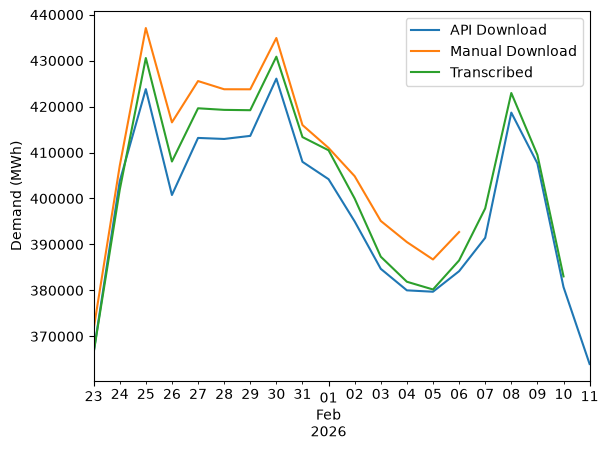

In [55]:
fig, ax = plt.subplots()
full_df.sum(axis=1).plot(ax=ax, label='API Download')
full_df_man.sum(axis=1).plot(ax=ax, label='Manual Download')
df.reindex(full_df.index).rename(columns={'MWh':'Transcribed'}).plot(ax=ax, label='Transcribed')
ax.legend()
ax.set_xlabel('')
ax.set_ylabel("Demand (MWh)")

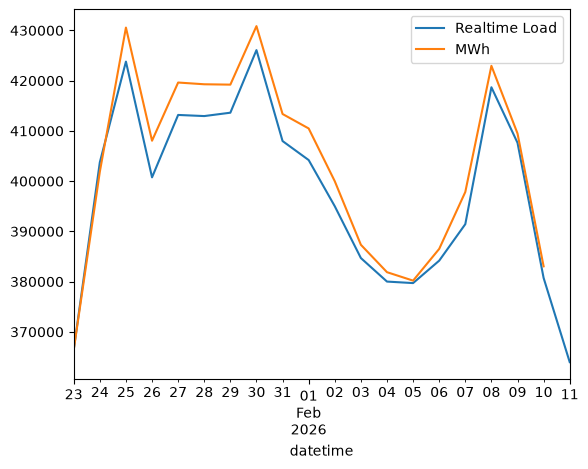

In [51]:
fig, ax = plt.subplots()
full_df.sum(axis=1).plot(ax=ax, label='Realtime Load')
df.reindex(full_df.index).plot(ax=ax, label='Unknown')
ax.legend()

In [73]:
BASE_URL = "https://webservices.iso-ne.com/api/v1.1"
market = "hourlysysload"
fmt = ".json"
dates = pd.date_range('2026-01-23','2026-02-11', freq='D')
day = date(2026, 1, 23)
location_ids = list(range(4001,4009))

auth = (os.environ["ISONE_USERNAME"], os.environ["ISONE_PASSWORD"])
frames = []
for d in tqdm(dates):
# for d in tqdm([day]):
    url = "/".join([BASE_URL, 
                    market, 
                    'day', 
                    d.strftime("%Y%m%d"), 
                    # 'location', 
                    # str(loc)
                    ]
                    ) + fmt
    r = requests.get(url, auth=auth, headers={"Accept":"application/json"})
    if r.status_code != 200:
        print(f"Status Code: {r.status_code} for url: {url}")
    df = pd.DataFrame(r.json()['HourlySystemLoads']['HourlySystemLoad'])
    df['BeginDate'] = pd.to_datetime(df['BeginDate'], utc=False)
    df = df[['BeginDate', 'Load','NativeLoad','ArdDemand']]
    df.set_index('BeginDate', inplace=True)
    frames.append(df)

100%|██████████| 20/20 [00:11<00:00,  1.67it/s]


In [70]:
df = pd.DataFrame(r.json()['HourlySystemLoads']['HourlySystemLoad'])
df['BeginDate'] = pd.to_datetime(df['BeginDate'], utc=False)
df = df[['BeginDate', 'Load','NativeLoad','ArdDemand']]
# df.columns = ['datetime',loc]
df.set_index('BeginDate', inplace=True)

In [75]:
hourlysys_df = pd.concat(frames, axis=0)
hourlysys_df

,Load,NativeLoad,ArdDemand
BeginDate,,,
2026-01-23 00:00:00-05:00,13800.667,13124.112,676.555
2026-01-23 01:00:00-05:00,13852.964,12778.091,1074.873
2026-01-23 02:00:00-05:00,13782.918,12678.198,1104.720
2026-01-23 03:00:00-05:00,13665.881,12729.387,936.494
2026-01-23 04:00:00-05:00,13874.880,13127.081,747.799
...,...,...,...
2026-02-11 19:00:00-05:00,17234.332,17230.171,4.161
2026-02-11 20:00:00-05:00,16734.840,16677.056,57.784
2026-02-11 21:00:00-05:00,16213.817,15945.274,268.543


<Axes: xlabel='BeginDate'>

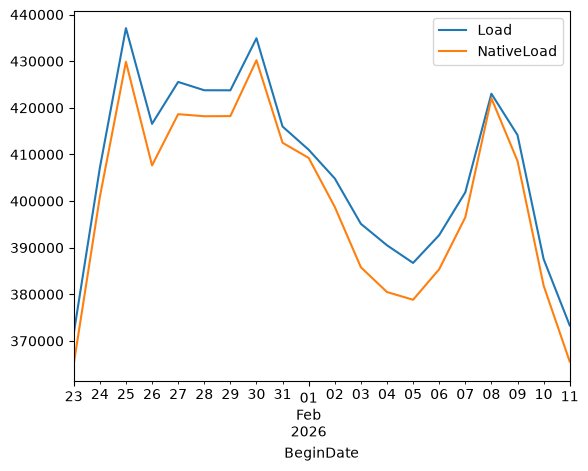

In [77]:
hourlysys_df.resample('D').sum()[['Load','NativeLoad']].plot()

Text(0, 0.5, 'Demand (MWh)')

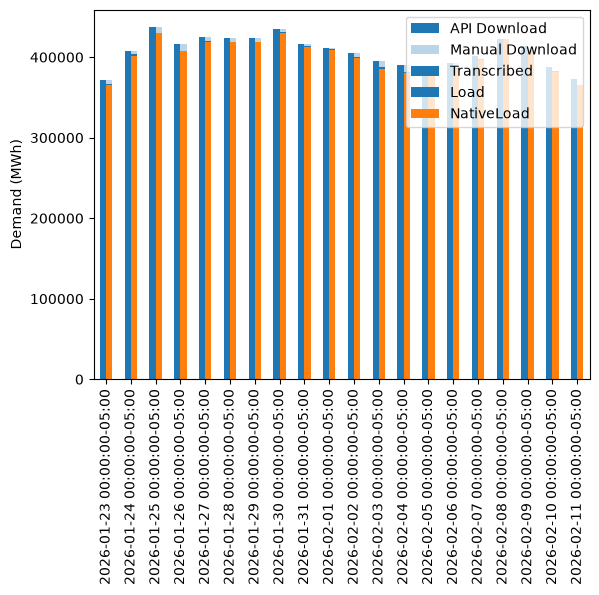

In [94]:
fig, ax = plt.subplots()
full_df.sum(axis=1).plot.bar(ax=ax, label='API Download')
full_df_man.sum(axis=1).plot.bar(ax=ax, label='Manual Download', lw=10, alpha=0.3)
trans_df.reindex(full_df.index).rename(columns={'MWh':'Transcribed'}).plot.bar(ax=ax, label='Transcribed')
hourlysys_df.resample('D').sum()[['Load','NativeLoad']].plot.bar(ax=ax)
ax.legend()
ax.set_xlabel('')
ax.set_ylabel("Demand (MWh)")

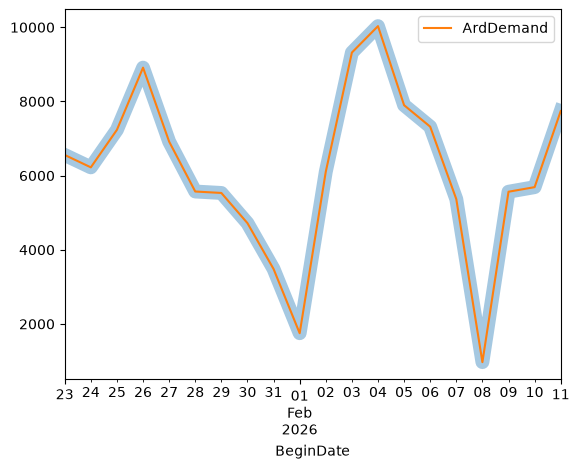

In [93]:
fig, ax = plt.subplots()
(hourlysys_df['Load']-hourlysys_df['NativeLoad']).resample('D').sum().plot(ax=ax, lw='10', alpha=0.4) 
hourlysys_df['ArdDemand'].resample('D').sum().plot(ax=ax) 
ax.legend()